# 03 — Risk Analysis
Assessing price sensitivity, concentration risk, substitution dynamics, and exchange-rate exposure in Singapore's bunker fuel market.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from fredapi import Fred
from dotenv import load_dotenv
from IPython.display import Markdown, display
import os

load_dotenv('../.env')
fred = Fred(api_key=os.getenv('FRED_API_KEY'))

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

In [2]:
# Load bunker data
annual_long = pd.read_csv('../data/cleaned/BunkerByCategoryLong.csv')
annual_wide = pd.read_csv('../data/cleaned/BunkerByCategoryWide.csv').set_index('year')
monthly = pd.read_csv('../data/cleaned/BunkerByCategoryMonthly.csv', parse_dates=['month'])

print(f'Annual data: {annual_wide.index.min()}–{annual_wide.index.max()}')
print(f'Fuel types: {list(annual_wide.columns)}')

Annual data: 1995–2025
Fuel types: ['Alternative', 'LNG', 'LSFO', 'LSMGO', 'MDO', 'MFO', 'MGO', 'ULSFO']


In [3]:
# Fetch Brent crude (DCOILBRENTEU) and USD/SGD (DEXSIUS) from FRED
brent_raw = fred.get_series('DCOILBRENTEU', observation_start='1995-01-01')
usdsgd_raw = fred.get_series('DEXSIUS', observation_start='1995-01-01')

# Annual averages
brent_annual = brent_raw.resample('YE').mean().reset_index()
brent_annual.columns = ['date', 'brent_avg']
brent_annual['year'] = brent_annual['date'].dt.year

usdsgd_annual = usdsgd_raw.resample('YE').mean().reset_index()
usdsgd_annual.columns = ['date', 'usdsgd_avg']
usdsgd_annual['year'] = usdsgd_annual['date'].dt.year

# Monthly averages for rolling correlation
brent_monthly = brent_raw.resample('ME').mean().reset_index()
brent_monthly.columns = ['month', 'brent_avg']
brent_monthly['month'] = brent_monthly['month'].dt.to_period('M').dt.to_timestamp()

print(f'Brent data: {brent_annual["year"].min()}–{brent_annual["year"].max()}')
print(f'USD/SGD data: {usdsgd_annual["year"].min()}–{usdsgd_annual["year"].max()}')

Brent data: 1995–2026
USD/SGD data: 1995–2026


## 1. Oil Price Sensitivity per Fuel Type

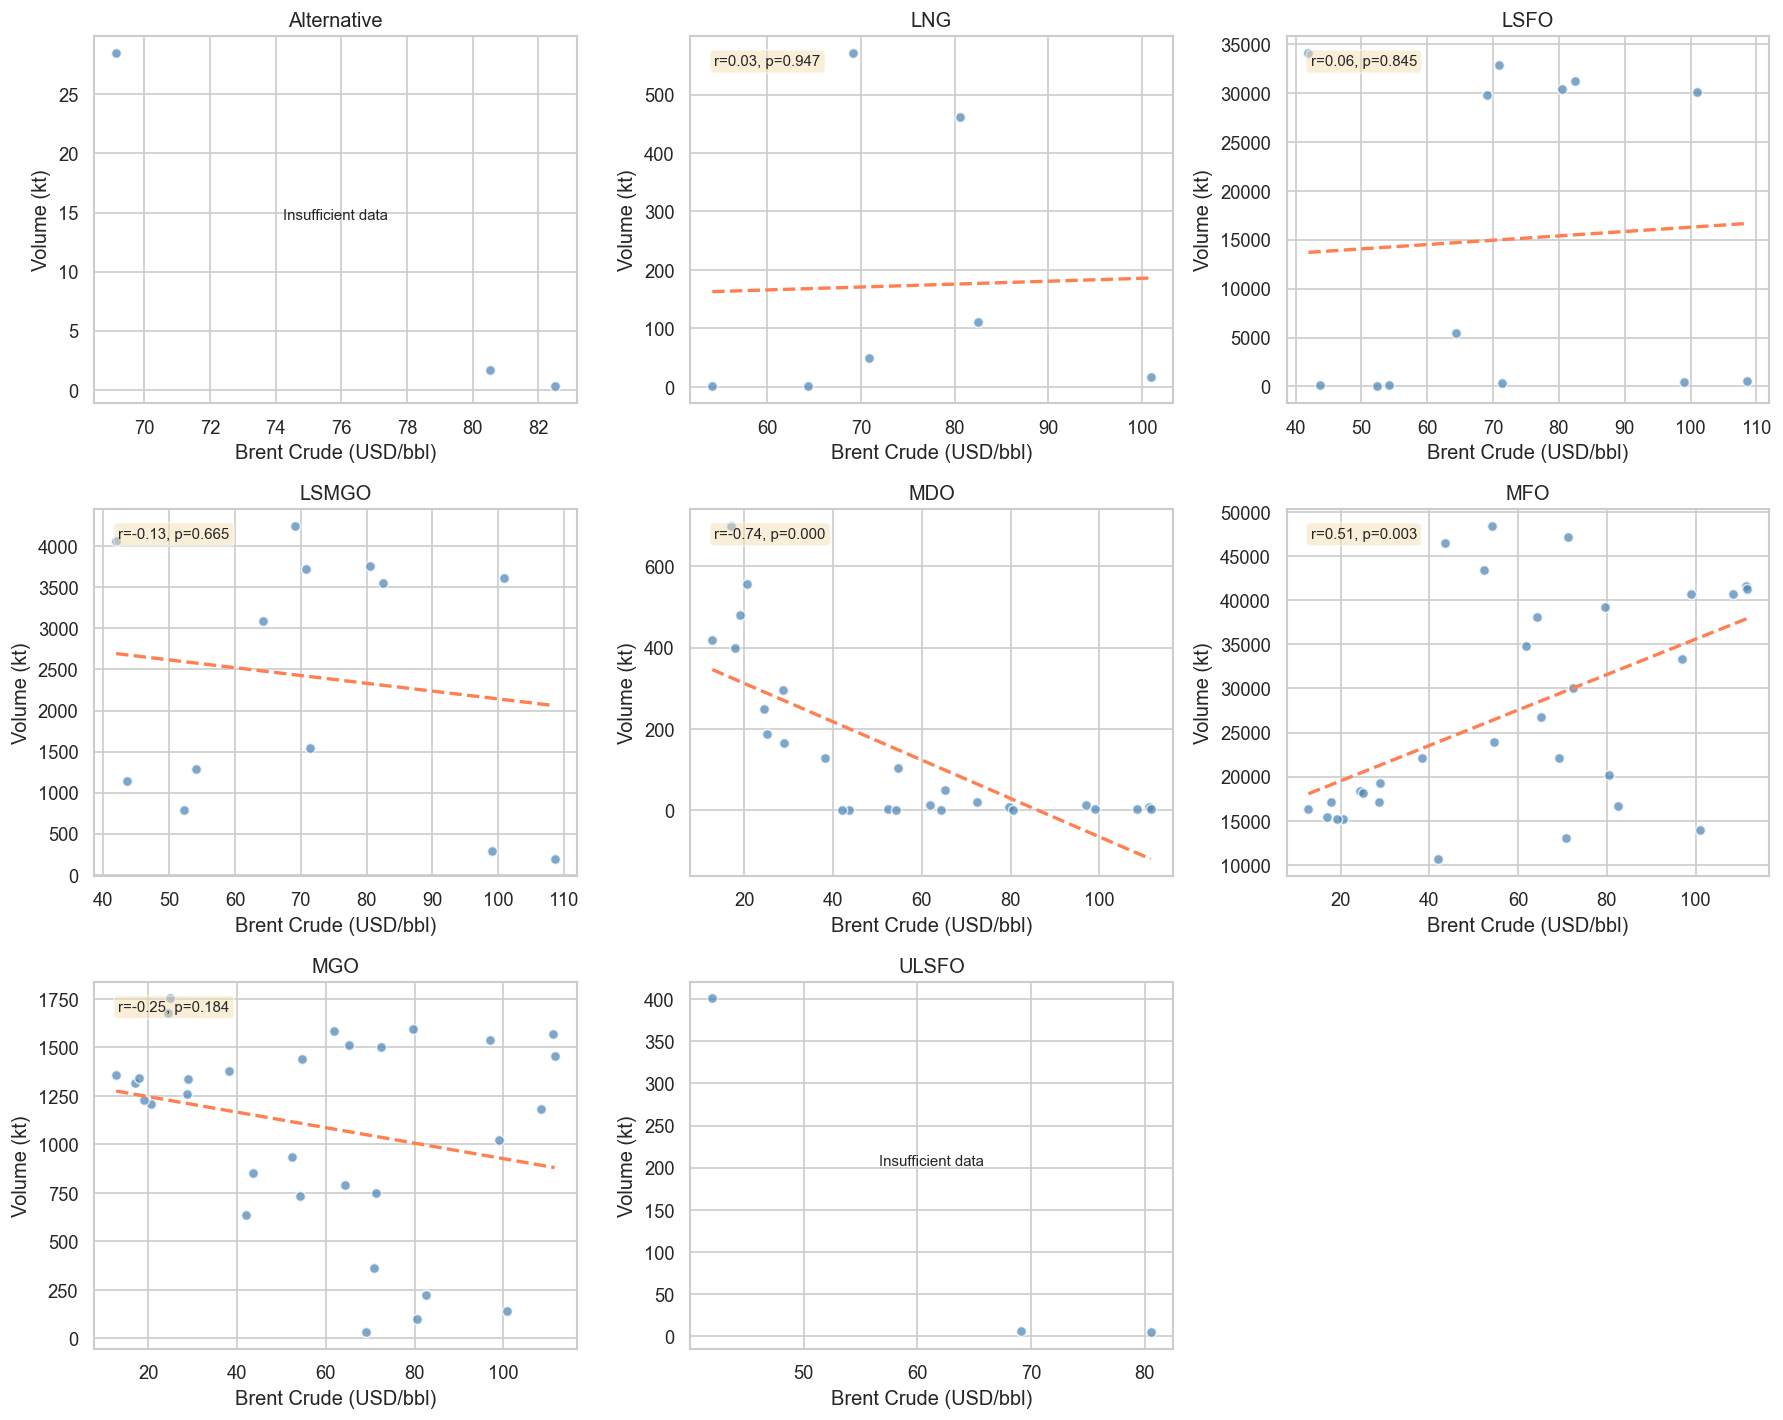

In [4]:
# Merge annual bunker volumes with Brent crude
fuel_annual = annual_long.groupby(['year', 'fuel_category'])['bunker_sales'].sum().reset_index()
merged = fuel_annual.merge(brent_annual[['year', 'brent_avg']], on='year', how='inner')

# Scatter plot grid — each fuel vs Brent
fuels = sorted(merged['fuel_category'].unique())
ncols = 3
nrows = int(np.ceil(len(fuels) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

corr_records = []

for i, fuel in enumerate(fuels):
    ax = axes[i]
    subset = merged[merged['fuel_category'] == fuel]
    subset = subset[subset['bunker_sales'] > 0]

    ax.scatter(subset['brent_avg'], subset['bunker_sales'], color='steelblue', alpha=0.7, edgecolors='white')
    ax.set_title(fuel)
    ax.set_xlabel('Brent Crude (USD/bbl)')
    ax.set_ylabel('Volume (kt)')

    if len(subset) >= 5:
        r, p = stats.pearsonr(subset['brent_avg'], subset['bunker_sales'])
        z = np.polyfit(subset['brent_avg'], subset['bunker_sales'], 1)
        x_line = np.linspace(subset['brent_avg'].min(), subset['brent_avg'].max(), 50)
        ax.plot(x_line, np.polyval(z, x_line), color='coral', linewidth=2, linestyle='--')
        ax.text(0.05, 0.95, f'r={r:.2f}, p={p:.3f}', transform=ax.transAxes, va='top', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        if p < 0.01:
            interp = 'Strong' if abs(r) > 0.7 else 'Moderate' if abs(r) > 0.4 else 'Weak'
        elif p < 0.05:
            interp = 'Moderate' if abs(r) > 0.4 else 'Weak'
        else:
            interp = 'Not significant'
        corr_records.append({'Fuel': fuel, 'r': r, 'p-value': p, 'Interpretation': interp})
    else:
        ax.text(0.5, 0.5, 'Insufficient data', transform=ax.transAxes, ha='center', fontsize=9)
        corr_records.append({'Fuel': fuel, 'r': np.nan, 'p-value': np.nan, 'Interpretation': 'Insufficient data'})

for j in range(len(fuels), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [5]:
# Summary table
corr_df = pd.DataFrame(corr_records).sort_values('r', key=abs, ascending=False)
display(corr_df.to_string(index=False))

# Insight
sig = corr_df[(corr_df['p-value'] < 0.05) & (corr_df['r'].notna())].sort_values('r', key=abs, ascending=False)
if not sig.empty:
    top = sig.iloc[0]
    direction = 'positively' if top['r'] > 0 else 'negatively'
    display(Markdown(f"**Insight:** {top['Fuel']} volumes are most sensitive to oil prices "
                     f"(r={top['r']:.2f}, p={top['p-value']:.3f}), {direction} correlated with Brent crude."))
else:
    display(Markdown('**Insight:** No fuel type shows a statistically significant correlation with Brent crude at p<0.05.'))

'       Fuel         r  p-value    Interpretation\n        MDO -0.735976 0.000018            Strong\n        MFO  0.509988 0.003380          Moderate\n        MGO -0.245212 0.183656   Not significant\n      LSMGO -0.132784 0.665420   Not significant\n       LSFO  0.060151 0.845237   Not significant\n        LNG  0.031243 0.946986   Not significant\nAlternative       NaN      NaN Insufficient data\n      ULSFO       NaN      NaN Insufficient data'

**Insight:** MDO volumes are most sensitive to oil prices (r=-0.74, p=0.000), negatively correlated with Brent crude.

## 2. Rolling Correlation (Monthly Drill-Down)

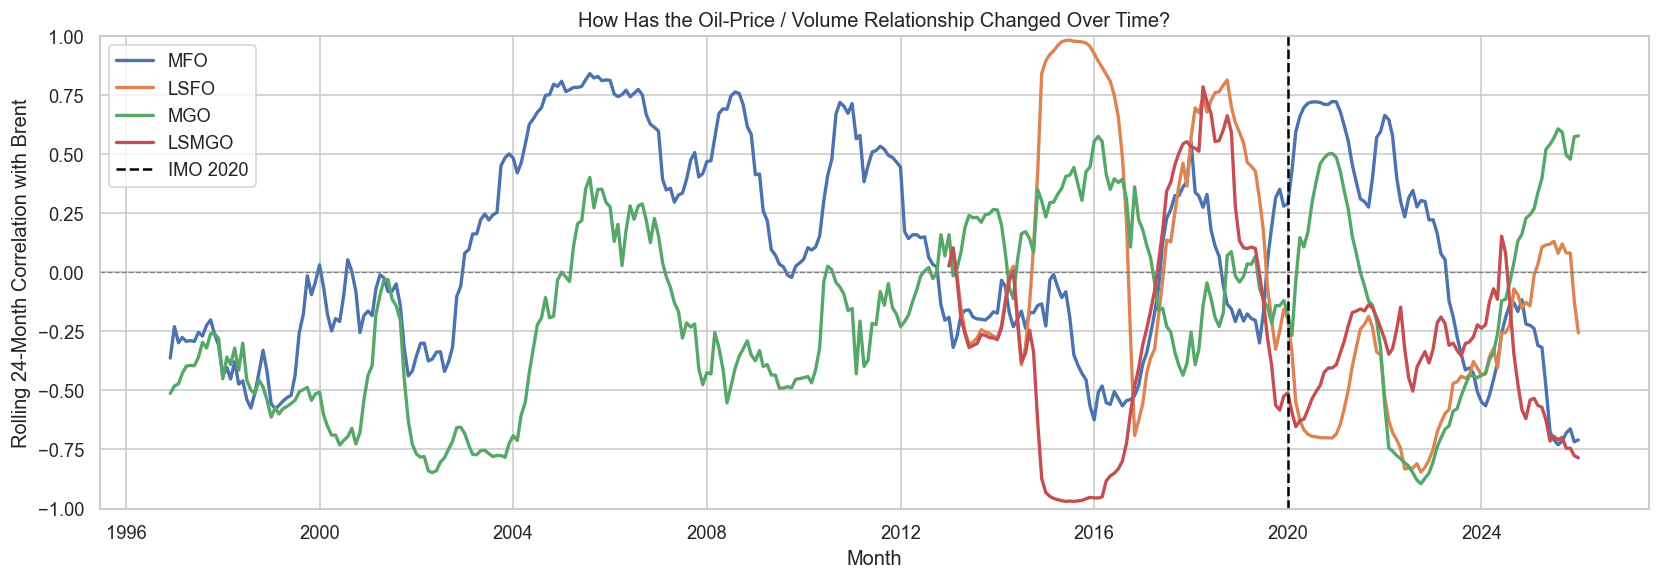

In [6]:
# Monthly volumes by fuel
monthly_vol = monthly.groupby(['month', 'fuel_category'])['bunker_sales'].sum().reset_index()
monthly_merged = monthly_vol.merge(brent_monthly, on='month', how='inner')

# Rolling 24-month correlation for key fuels
key_fuels = ['MFO', 'LSFO', 'MGO', 'LSMGO']
available = [f for f in key_fuels if f in monthly_merged['fuel_category'].unique()]

fig, ax = plt.subplots(figsize=(14, 5))

for fuel in available:
    sub = monthly_merged[monthly_merged['fuel_category'] == fuel].sort_values('month').set_index('month')
    rolling_corr = sub['bunker_sales'].rolling(24).corr(sub['brent_avg'])
    ax.plot(rolling_corr.index, rolling_corr, linewidth=2, label=fuel)

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.axvline(pd.Timestamp('2020-01-01'), color='black', linestyle='--', linewidth=1.5, label='IMO 2020')
ax.set_xlabel('Month')
ax.set_ylabel('Rolling 24-Month Correlation with Brent')
ax.set_title('How Has the Oil-Price / Volume Relationship Changed Over Time?')
ax.legend()
ax.set_ylim(-1, 1)
plt.tight_layout()
plt.show()

## 3. Concentration Risk (HHI)

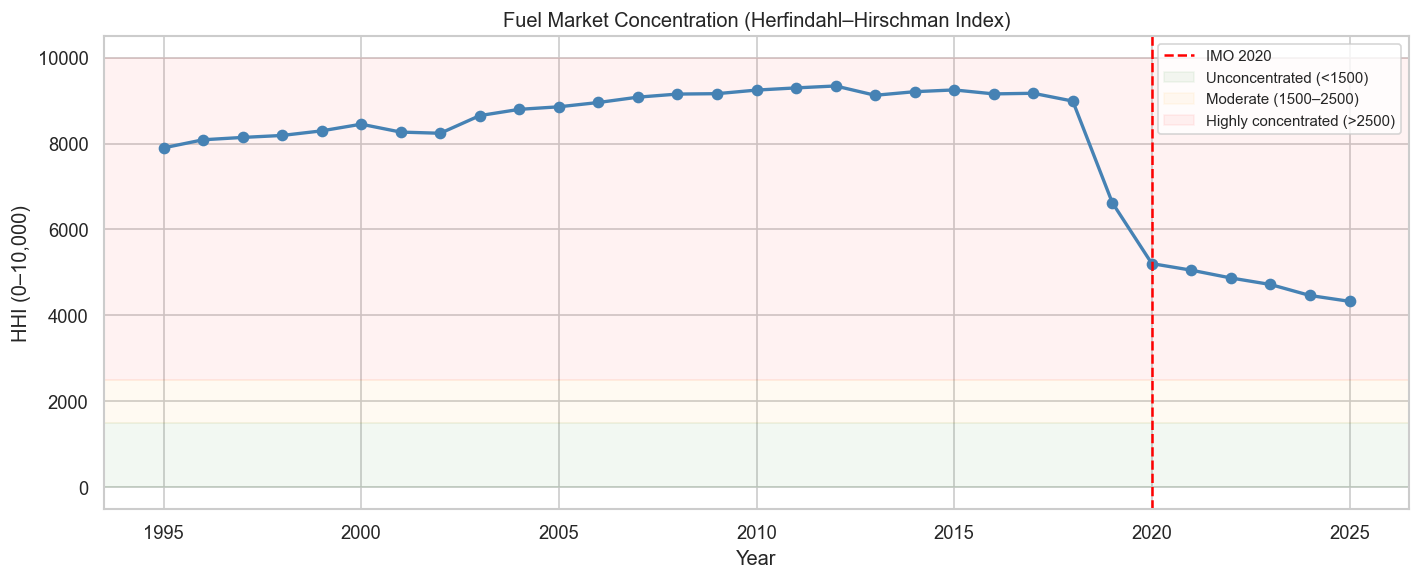

**Insight:** Market concentration decreased by 2297 HHI points from 6622 (2019) to 4325 (2025). IMO 2020 fragmented the fuel mix, reducing single-fuel dominance.

In [7]:
# HHI = sum of squared market shares (each as percentage, so max = 10,000)
pct = annual_wide.div(annual_wide.sum(axis=1), axis=0) * 100
hhi = (pct ** 2).sum(axis=1)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hhi.index, hhi.values, marker='o', color='steelblue', linewidth=2)
ax.axvline(2020, color='red', linestyle='--', linewidth=1.5, label='IMO 2020')
ax.set_xlabel('Year')
ax.set_ylabel('HHI (0–10,000)')
ax.set_title('Fuel Market Concentration (Herfindahl–Hirschman Index)')

# Reference bands
ax.axhspan(0, 1500, alpha=0.05, color='green', label='Unconcentrated (<1500)')
ax.axhspan(1500, 2500, alpha=0.05, color='orange', label='Moderate (1500–2500)')
ax.axhspan(2500, 10000, alpha=0.05, color='red', label='Highly concentrated (>2500)')
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

# Insight
hhi_2019 = hhi.loc[2019]
hhi_post = hhi.loc[hhi.index >= 2020]
hhi_latest = hhi_post.iloc[-1]
hhi_latest_year = hhi_post.index[-1]
delta = hhi_latest - hhi_2019
direction = 'decreased' if delta < 0 else 'increased'
display(Markdown(
    f'**Insight:** Market concentration {direction} by {abs(delta):.0f} HHI points '
    f'from {hhi_2019:.0f} (2019) to {hhi_latest:.0f} ({hhi_latest_year}). '
    f'IMO 2020 fragmented the fuel mix, reducing single-fuel dominance.'
))

## 4. MFO vs LSFO Substitution

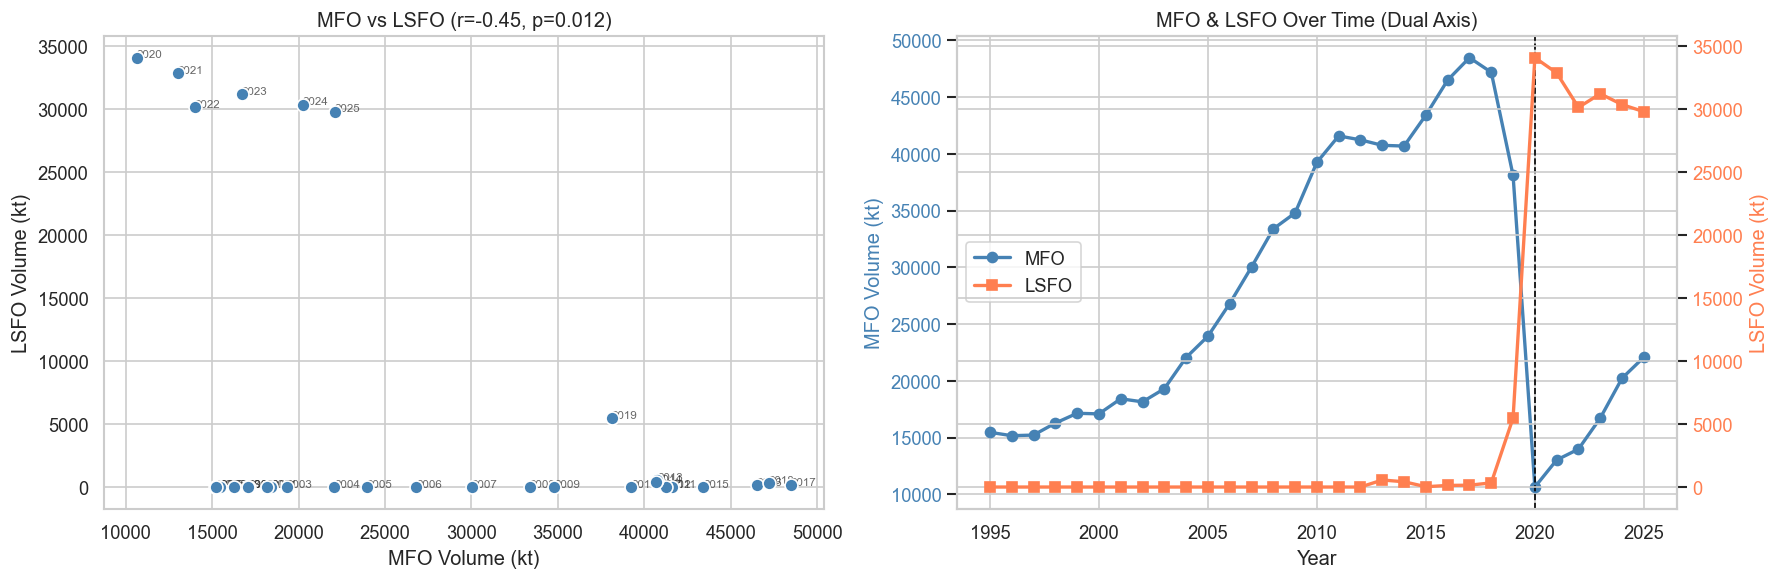

> **Note:** This is **regulation-driven substitution**, not market causation. IMO 2020 mandated the 0.50% sulphur cap, forcing a shift from high-sulphur MFO to compliant LSFO. The inverse correlation reflects regulatory compliance, not price-driven behaviour.

In [8]:
# MFO vs LSFO — scatter + dual-axis time series
sub = annual_wide[['MFO', 'LSFO']].copy()
sub = sub[(sub['MFO'] > 0) | (sub['LSFO'] > 0)]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter: inverse relationship
ax = axes[0]
ax.scatter(sub['MFO'], sub['LSFO'], color='steelblue', s=60, edgecolors='white', zorder=5)
for yr in sub.index:
    ax.annotate(str(yr), (sub.loc[yr, 'MFO'], sub.loc[yr, 'LSFO']), fontsize=7, alpha=0.7)
r, p = stats.pearsonr(sub['MFO'], sub['LSFO'])
ax.set_xlabel('MFO Volume (kt)')
ax.set_ylabel('LSFO Volume (kt)')
ax.set_title(f'MFO vs LSFO (r={r:.2f}, p={p:.3f})')

# Dual-axis time series
ax1 = axes[1]
ax1.plot(sub.index, sub['MFO'], color='steelblue', marker='o', linewidth=2, label='MFO')
ax1.set_xlabel('Year')
ax1.set_ylabel('MFO Volume (kt)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(sub.index, sub['LSFO'], color='coral', marker='s', linewidth=2, label='LSFO')
ax2.set_ylabel('LSFO Volume (kt)', color='coral')
ax2.tick_params(axis='y', labelcolor='coral')

ax1.axvline(2020, color='black', linestyle='--', linewidth=1)
axes[1].set_title('MFO & LSFO Over Time (Dual Axis)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')

plt.tight_layout()
plt.show()

display(Markdown(
    '> **Note:** This is **regulation-driven substitution**, not market causation. '
    'IMO 2020 mandated the 0.50% sulphur cap, forcing a shift from high-sulphur MFO '
    'to compliant LSFO. The inverse correlation reflects regulatory compliance, not price-driven behaviour.'
))

## 5. Exchange Rate Analysis — USD/SGD vs Total Bunker Demand

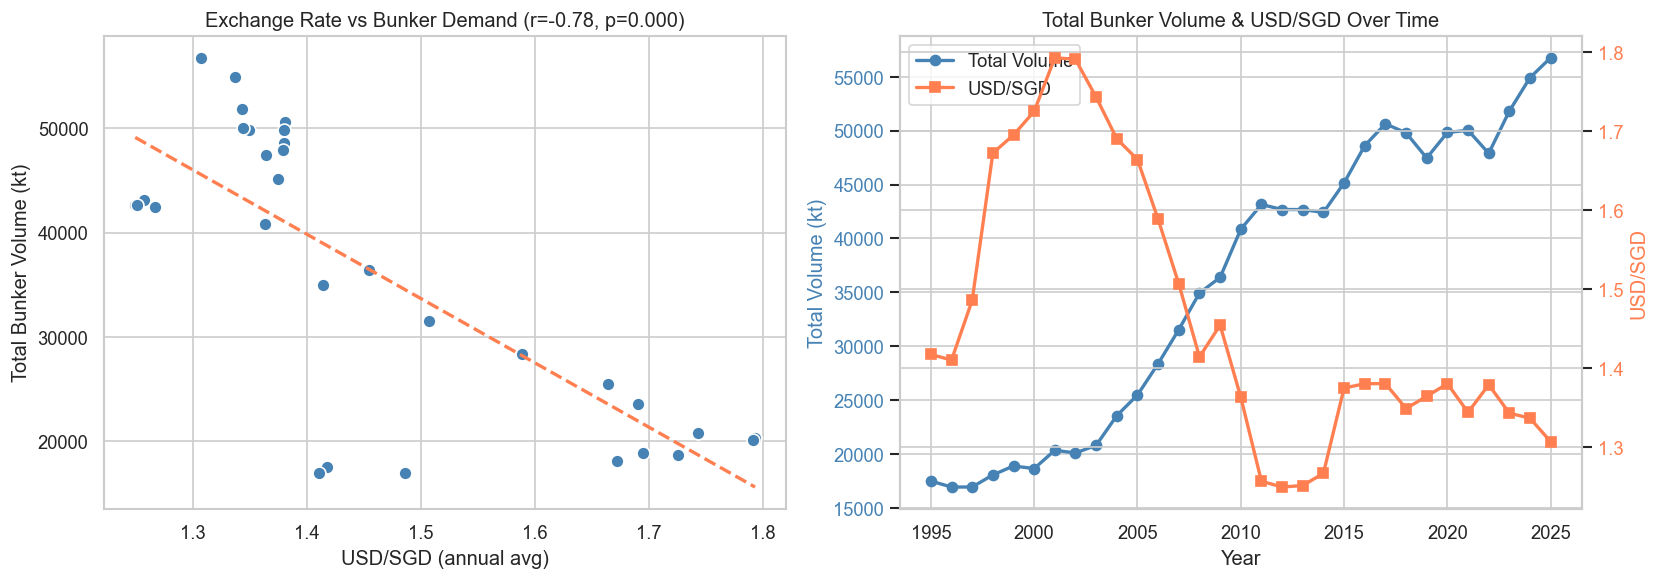

**Insight:** USD/SGD is negatively correlated with total bunker demand (r=-0.78, p=0.000).

In [9]:
# Total annual bunker demand vs USD/SGD
total_annual = annual_wide.sum(axis=1).reset_index()
total_annual.columns = ['year', 'total_volume']
fx_merged = total_annual.merge(usdsgd_annual[['year', 'usdsgd_avg']], on='year', how='inner')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
ax = axes[0]
ax.scatter(fx_merged['usdsgd_avg'], fx_merged['total_volume'], color='steelblue', s=60, edgecolors='white')
r_fx, p_fx = stats.pearsonr(fx_merged['usdsgd_avg'], fx_merged['total_volume'])
if len(fx_merged) >= 3:
    z = np.polyfit(fx_merged['usdsgd_avg'], fx_merged['total_volume'], 1)
    x_line = np.linspace(fx_merged['usdsgd_avg'].min(), fx_merged['usdsgd_avg'].max(), 50)
    ax.plot(x_line, np.polyval(z, x_line), color='coral', linewidth=2, linestyle='--')
ax.set_xlabel('USD/SGD (annual avg)')
ax.set_ylabel('Total Bunker Volume (kt)')
ax.set_title(f'Exchange Rate vs Bunker Demand (r={r_fx:.2f}, p={p_fx:.3f})')

# Dual-axis time series
ax1 = axes[1]
ax1.plot(fx_merged['year'], fx_merged['total_volume'], color='steelblue', marker='o', linewidth=2, label='Total Volume')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Volume (kt)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(fx_merged['year'], fx_merged['usdsgd_avg'], color='coral', marker='s', linewidth=2, label='USD/SGD')
ax2.set_ylabel('USD/SGD', color='coral')
ax2.tick_params(axis='y', labelcolor='coral')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
axes[1].set_title('Total Bunker Volume & USD/SGD Over Time')

plt.tight_layout()
plt.show()

# Insight
if p_fx < 0.05:
    direction = 'positively' if r_fx > 0 else 'negatively'
    display(Markdown(f'**Insight:** USD/SGD is {direction} correlated with total bunker demand (r={r_fx:.2f}, p={p_fx:.3f}).'))
else:
    display(Markdown(f'**Insight:** No statistically significant relationship between USD/SGD and total bunker demand '
                     f'(r={r_fx:.2f}, p={p_fx:.3f}). Exchange rate fluctuations do not appear to drive bunker purchasing decisions — '
                     f'this is expected, as bunker fuel is priced in USD globally.'))

## 6. Risk Summary Table

In [10]:
# Compile risk summary
risk_data = [
    {
        'Risk Factor': 'Oil price sensitivity',
        'Affected Segments': ', '.join(sig['Fuel'].tolist()) if not sig.empty else 'None significant',
        'Likelihood': 'High' if not sig.empty else 'Low',
        'Impact': 'Volume shifts across fuel types when crude prices swing',
        'Mitigation': 'Monitor Brent crude; price-sensitive fuels may see demand substitution'
    },
    {
        'Risk Factor': 'Fuel concentration risk',
        'Affected Segments': 'Whole market',
        'Likelihood': 'Medium',
        'Impact': f'HHI at {hhi_latest:.0f} — {"high" if hhi_latest > 2500 else "moderate" if hhi_latest > 1500 else "low"} concentration',
        'Mitigation': 'Diversification trend post-IMO 2020 is positive; monitor for re-concentration'
    },
    {
        'Risk Factor': 'Regulatory substitution (MFO → LSFO)',
        'Affected Segments': 'MFO, LSFO',
        'Likelihood': 'Already materialised',
        'Impact': 'Near-complete substitution of MFO by LSFO in compliant segments',
        'Mitigation': 'Structural shift is complete; monitor future ECA / CII regulation for next wave'
    },
    {
        'Risk Factor': 'Exchange rate exposure (USD/SGD)',
        'Affected Segments': 'Total market',
        'Likelihood': 'Low',
        'Impact': f'r={r_fx:.2f}, p={p_fx:.3f} — {"significant" if p_fx < 0.05 else "not significant"}',
        'Mitigation': 'USD-denominated market limits FX impact; no action required'
    },
    {
        'Risk Factor': 'Emerging fuel disruption (LNG, Alternative)',
        'Affected Segments': 'LNG, Alternative, potentially LSFO',
        'Likelihood': 'Medium (5–10 year horizon)',
        'Impact': 'Could erode LSFO dominance if green corridors / carbon pricing expand',
        'Mitigation': 'Track LNG bunkering infrastructure buildout and regulatory signals'
    }
]

risk_df = pd.DataFrame(risk_data)
display(risk_df.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'left')]}]
))

,Risk Factor,Affected Segments,Likelihood,Impact,Mitigation
0,Oil price sensitivity,"MDO, MFO",High,Volume shifts across fuel types when crude prices swing,Monitor Brent crude; price-sensitive fuels may see demand substitution
1,Fuel concentration risk,Whole market,Medium,HHI at 4325 — high concentration,Diversification trend post-IMO 2020 is positive; monitor for re-concentration
2,Regulatory substitution (MFO → LSFO),"MFO, LSFO",Already materialised,Near-complete substitution of MFO by LSFO in compliant segments,Structural shift is complete; monitor future ECA / CII regulation for next wave
3,Exchange rate exposure (USD/SGD),Total market,Low,"r=-0.78, p=0.000 — significant",USD-denominated market limits FX impact; no action required
4,"Emerging fuel disruption (LNG, Alternative)","LNG, Alternative, potentially LSFO",Medium (5–10 year horizon),Could erode LSFO dominance if green corridors / carbon pricing expand,Track LNG bunkering infrastructure buildout and regulatory signals
